# K-Means Clustering of Chicken Calls By Acoustic Features
K-Means clustering is an unsupervised machine learning technique to cluster cases into groups by their features. It's a method of partitional clustering, where every case must fit in one and only one group. In this project, individual chicken calls were clustered by the numerical features extracted from the audio. 

For this analysis, both chick and adult chicken calls were included.

Steps
1. Import and visualize data using a scatterplot
2. Drop metadata columns
3. Use StandardScaler to get all variables on the same scale
4. Use principal components analysis (PCA) to reduce the number of variables
4. Use Elbow method to determine best number of clusters
5. Use K-means clustering to fit cases into clusters and append to original data
6. Explore characterstics of the clusters and plot using a scatterplot
7. Export results

Author: K Rubio

Last modified: 31Jul26

Dataset Information

Data created by using voice activity detection (VAD) to separate out individual calls from larger recordings, then for each call, audio features were extracted including zero-crossing rate, MFCCs 0-9, spectral centroid and bandwidth, etc. Program: chicken_feature_extraction_semi_automated.ipynb

1095 rows (one row per individual chicken call of varying durations)

Dataset columns include:
metadata
1.	filename
2.	call_num
3.	start
4.	end
5.	sample_rate
6.	frame_length
7.	vad_energy_threshold_used

audio features
1.	duration_ms
2.	time_to_next_call_ms
3.	min_freq
4.	max_freq
5.	max_energy_freq
6.	seg1_max_energy_freq
7.	seg2_max_energy_freq
8.	seg3_max_energy_freq
9.	freq_change
10.	slope
11.	zcr
12.	mfcc0_avg
13.	mfcc0_std
14.	mfcc0_min
15.	mfcc0_max
16.	mfcc1_avg
17.	mfcc1_std
18.	mfcc1_min
19.	mfcc1_max
20.	mfcc2_avg
21.	mfcc2_std
22.	mfcc2_min
23.	mfcc2_max
24.	mfcc3_avg
25.	mfcc3_std
26.	mfcc3_min
27.	mfcc3_max
28.	mfcc4_avg
29.	mfcc4_std
30.	mfcc4_min
31.	mfcc4_max
32.	mfcc5_avg
33.	mfcc5_std
34.	mfcc5_min
35.	mfcc5_max
36.	mfcc6_avg
37.	mfcc6_std
38.	mfcc6_min
39.	mfcc6_max
40.	mfcc7_avg
41.	mfcc7_std
42.	mfcc7_min
43.	mfcc7_max
44.	mfcc8_avg
45.	mfcc8_std
46.	mfcc8_min
47.	mfcc8_max
48.	mfcc9_avg
49.	mfcc9_std
50.	mfcc9_min
51.	mfcc9_max	
52.	spectral_centroid
53.	spectral_bandwidth


In [ ]:
import matplotlib.pyplot as plt
from kneed import KneeLocator
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd
from scipy.stats import zscore
import seaborn as sns
from sklearn.model_selection import train_test_split
import os
import sys
from pathlib import Path
from datetime import date

In [6]:
# have to modify where notebook looks for imports so it looks in the project root, not the notebook folder
os.getcwd()
sys.path.append(str(Path().resolve().parent.parent))
print(sys.path)

['/Users/dontfreakout/.pyenv/versions/3.12.8/lib/python312.zip', '/Users/dontfreakout/.pyenv/versions/3.12.8/lib/python3.12', '/Users/dontfreakout/.pyenv/versions/3.12.8/lib/python3.12/lib-dynload', '', '/Users/dontfreakout/Documents/Education (reduced)/Computer_Science/ML_and_Data_Science/Audio Signal Processing/Completed Projects/2026_04_Audio_Signal_Analysis/audio-signal-analysis/.venv/lib/python3.12/site-packages', '/Users/dontfreakout/Documents/Education (reduced)/Computer_Science/ML_and_Data_Science/Audio Signal Processing/Completed Projects/2026_04_Audio_Signal_Analysis/audio-signal-analysis']


## Data Preparation

In [39]:
# import the data
filename = "chicken_call_audio_features_ready_for_clustering"
df = pd.read_csv(f"../../data/output/chickens/{filename}.csv")
df

,filename,call_num,start,end,duration_ms,time_to_next_call_ms,min_freq,max_freq,max_energy_freq,seg1_max_energy_freq,...,mfcc8_max,mfcc9_avg,mfcc9_std,mfcc9_min,mfcc9_max,spectral_centroid,spectral_bandwidth,sample_rate,frame_length,vad_energy_threshold_used
0,chickens_20250925_disturbed_at_nest_box2.wav,1,0.386,0.508,122,36.0,1205.859375,1421.191406,1335.058594,1335.058594,...,-14.538152,-18.597576,6.832009,-33.007959,-9.699238,2905.300460,2624.356786,22050,512,0.001
1,chickens_20250925_disturbed_at_nest_box2.wav,2,0.544,1.244,700,302.0,1033.593750,1378.125000,1119.726563,1291.992188,...,2.774709,-23.577801,18.308346,-60.801953,26.842424,1871.231320,1644.881799,22050,512,0.001
2,chickens_20250925_disturbed_at_nest_box2.wav,3,1.546,2.146,600,416.0,1076.660156,1248.925781,1119.726563,1119.726563,...,-13.332011,-28.341134,15.835605,-60.057400,-0.252303,1723.434437,1378.180724,22050,512,0.001
3,chickens_20250925_disturbed_at_nest_box2.wav,4,2.562,3.046,484,354.0,689.062500,1076.660156,1033.593750,1033.593750,...,25.669295,-14.385332,20.285077,-48.250835,16.092685,1400.304624,1286.143802,22050,512,0.001
4,chickens_20250925_disturbed_at_nest_box2.wav,5,3.400,3.930,530,NaN,1033.593750,1335.058594,1119.726563,1119.726563,...,10.740865,-9.885018,12.432922,-48.367343,19.022781,1801.598218,1627.250258,22050,512,0.001
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1090,chickens_20201025_murmurs.wav,2,1.078,1.200,122,122.0,172.265625,1076.660156,215.332031,215.332031,...,10.484846,-9.869200,6.042165,-22.127784,4.626768,1653.708501,2150.898274,22050,512,0.005
1091,chickens_20201025_murmurs.wav,3,1.322,1.658,336,NaN,129.199219,1076.660156,387.597656,344.531250,...,-1.260312,-18.895694,7.992846,-40.085477,3.197494,1728.824871,2263.841987,22050,512,0.005
1092,chickens_20241006_0600_coop_low_growl.wav,1,1.582,1.724,142,38.0,129.199219,818.261719,258.398438,215.332031,...,6.496047,-3.797614,6.702341,-15.636600,11.868881,1970.696584,2664.557015,22050,512,0.005
1093,chickens_20241006_0600_coop_low_growl.wav,2,1.762,2.266,504,26.0,172.265625,645.996094,258.398438,258.398438,...,5.026454,-14.499473,8.506499,-35.763092,5.924839,1864.329548,2631.823427,22050,512,0.005


In [40]:
print(f"Number of missing values in time_to_next_call: {df['time_to_next_call_ms'].isna().sum()}")

Number of missing values in time_to_next_call: 143


In [41]:
# Handle missing data in the "time_to_next_call" variable by replacing it with the mean from all rows
# that have the same filename
df["time_to_next_call_ms"] = (
    df["time_to_next_call_ms"]
      .fillna(
          df.groupby("filename")["time_to_next_call_ms"]
            .transform("mean")
      )
)
print(f"Number of missing values in time_to_next_call: {df['time_to_next_call_ms'].isna().sum()}")

Number of missing values in time_to_next_call: 19


In [42]:
# Since some calls were alone in their file, replace with overall mean
mean = df["time_to_next_call_ms"].mean()
df.fillna({"time_to_next_call_ms": mean}, inplace=True)
print(f"Number of missing values in time_to_next_call: {df['time_to_next_call_ms'].isna().sum()}")

Number of missing values in time_to_next_call: 0


In [43]:
cols_to_drop = ['filename', 'call_num', 'start', 'end', 'sample_rate', 'frame_length', 'vad_energy_threshold_used']
df2 = df.drop(cols_to_drop, axis=1, inplace=False)
df2

,duration_ms,time_to_next_call_ms,min_freq,max_freq,max_energy_freq,seg1_max_energy_freq,seg2_max_energy_freq,seg3_max_energy_freq,freq_change,slope,...,mfcc8_avg,mfcc8_std,mfcc8_min,mfcc8_max,mfcc9_avg,mfcc9_std,mfcc9_min,mfcc9_max,spectral_centroid,spectral_bandwidth
0,122,36.000000,1205.859375,1421.191406,1335.058594,1335.058594,1291.992188,1378.125000,86.132812,353.003330,...,-36.094513,10.665915,-53.730093,-14.538152,-18.597576,6.832009,-33.007959,-9.699238,2905.300460,2624.356786
1,700,302.000000,1033.593750,1378.125000,1119.726563,1291.992188,1291.992188,1076.660156,215.332031,-307.617188,...,-34.062546,13.940853,-65.177905,2.774709,-23.577801,18.308346,-60.801953,26.842424,1871.231320,1644.881799
2,600,416.000000,1076.660156,1248.925781,1119.726563,1119.726563,1119.726563,1119.726563,0.000000,0.000000,...,-38.068981,12.055237,-67.606766,-13.332011,-28.341134,15.835605,-60.057400,-0.252303,1723.434437,1378.180724
3,484,354.000000,689.062500,1076.660156,1033.593750,1033.593750,990.527344,732.128906,301.464844,-622.861247,...,-2.742786,14.347669,-33.636340,25.669295,-14.385332,20.285077,-48.250835,16.092685,1400.304624,1286.143802
4,530,222.222222,1033.593750,1335.058594,1119.726563,1119.726563,1076.660156,1119.726563,43.066406,0.000000,...,-14.716567,14.359764,-58.971959,10.740865,-9.885018,12.432922,-48.367343,19.022781,1801.598218,1627.250258
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1090,122,122.000000,172.265625,1076.660156,215.332031,215.332031,215.332031,215.332031,0.000000,0.000000,...,-9.554047,7.066249,-19.091608,10.484846,-9.869200,6.042165,-22.127784,4.626768,1653.708501,2150.898274
1091,336,90.000000,129.199219,1076.660156,387.597656,344.531250,387.597656,473.730469,129.199219,384.521484,...,-17.432987,6.289781,-27.487254,-1.260312,-18.895694,7.992846,-40.085477,3.197494,1728.824871,2263.841987
1092,142,38.000000,129.199219,818.261719,258.398438,215.332031,258.398438,258.398438,43.066406,303.284551,...,-6.936776,6.410327,-20.430043,6.496047,-3.797614,6.702341,-15.636600,11.868881,1970.696584,2664.557015
1093,504,26.000000,172.265625,645.996094,258.398438,258.398438,258.398438,258.398438,0.000000,0.000000,...,-16.382412,8.460439,-40.154185,5.026454,-14.499473,8.506499,-35.763092,5.924839,1864.329548,2631.823427


In [44]:
scaler = StandardScaler()
X = scaler.fit_transform(df2)
X

array([[-0.28154049, -0.4084946 ,  0.12319353, ..., -1.31881176,
         0.61965017,  2.44814047],
       [ 2.03477857,  0.07238931, -0.01473788, ...,  0.48387479,
        -0.31427665, -0.16114014],
       [ 1.63403133,  0.27848242,  0.01974498, ..., -0.85277212,
        -0.44776045, -0.8716207 ],
       ...,
       [-0.20139104, -0.40487893, -0.73887778, ..., -0.25480548,
        -0.2244439 ,  2.55523221],
       [ 1.24931398, -0.42657294, -0.70439493, ..., -0.54803912,
        -0.32051004,  2.46803129],
       [ 0.11119181, -0.41572594, -0.70439493, ..., -0.6523906 ,
        -0.59488719,  1.99569646]])

## Principal Component Analysis

In [45]:
# Fit PCA without specifying the number of components, since this is unknown
pca = PCA()
X_pca = pca.fit_transform(X)

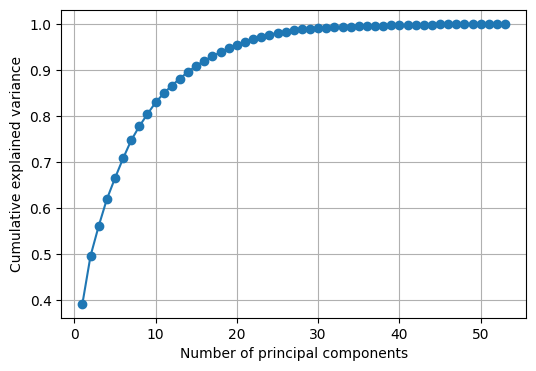

In [46]:
# Visualize how many components are needed to explain a certain % of variance in the dataset
plt.figure(figsize=(6,4))
plt.plot(
    range(1, len(pca.explained_variance_ratio_) + 1),
    pca.explained_variance_ratio_.cumsum(),
    marker="o"
)
plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance")
plt.grid(True)
plt.show()

In [47]:
# Keep enough components to explain about 95% of the variance. Should be around 20 based on the graph above
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X)
print(pca.n_components_)

20


This means original 53 features were compressed into 20 principal components

In [48]:
X_pca

array([[ 1.1529614 ,  1.050566  ,  5.99921974, ...,  0.87001762,
         0.85614446,  1.49181493],
       [ 2.5624499 , -5.60836507,  4.22248495, ...,  0.55925001,
         0.7888581 ,  0.29413256],
       [ 0.56024602, -4.03969589,  4.12273371, ...,  0.71149019,
         0.44062472,  0.22712328],
       ...,
       [-3.01343938,  4.25628804,  0.90832449, ..., -0.42640611,
        -0.21950727,  0.37842906],
       [-2.50624742,  2.44504558,  0.82139123, ..., -0.28939941,
        -0.40133524,  0.16700473],
       [-3.15990834,  4.08643042,  1.03977928, ...,  0.25862411,
        -0.24539452,  0.48580798]])

## K-Means Clustering

<Axes: >

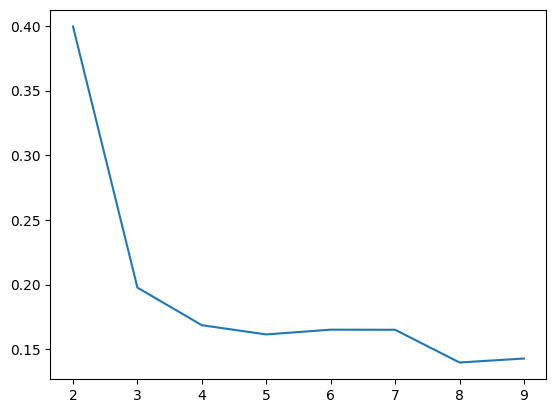

In [49]:
# Elbow method to determine best number of clusters
K = range(2, 10)
fits = []
score = []

for k in K:
    model = KMeans(n_clusters = k, random_state = 0, n_init='auto').fit(X_pca)
    fits.append(model)
    # Append the silhouette score to scores
    score.append(silhouette_score(X_pca, model.labels_, metric='euclidean'))
sns.lineplot(x = K, y = score)

Based on this graph, some good options include 5 or 8 clusters. Since chicken calls are expected to be pretty diverse, will go with 8 clusters

In [50]:
k = 8 # number of groups
kmeans = KMeans(n_clusters=k, random_state=0) # initialize kmeans algorithm
labels = kmeans.fit_predict(X_pca) # fit and predict to generate labels
df['cluster'] = labels # append those labels to the original df
df

,filename,call_num,start,end,duration_ms,time_to_next_call_ms,min_freq,max_freq,max_energy_freq,seg1_max_energy_freq,...,mfcc9_avg,mfcc9_std,mfcc9_min,mfcc9_max,spectral_centroid,spectral_bandwidth,sample_rate,frame_length,vad_energy_threshold_used,cluster
0,chickens_20250925_disturbed_at_nest_box2.wav,1,0.386,0.508,122,36.000000,1205.859375,1421.191406,1335.058594,1335.058594,...,-18.597576,6.832009,-33.007959,-9.699238,2905.300460,2624.356786,22050,512,0.001,1
1,chickens_20250925_disturbed_at_nest_box2.wav,2,0.544,1.244,700,302.000000,1033.593750,1378.125000,1119.726563,1291.992188,...,-23.577801,18.308346,-60.801953,26.842424,1871.231320,1644.881799,22050,512,0.001,0
2,chickens_20250925_disturbed_at_nest_box2.wav,3,1.546,2.146,600,416.000000,1076.660156,1248.925781,1119.726563,1119.726563,...,-28.341134,15.835605,-60.057400,-0.252303,1723.434437,1378.180724,22050,512,0.001,0
3,chickens_20250925_disturbed_at_nest_box2.wav,4,2.562,3.046,484,354.000000,689.062500,1076.660156,1033.593750,1033.593750,...,-14.385332,20.285077,-48.250835,16.092685,1400.304624,1286.143802,22050,512,0.001,0
4,chickens_20250925_disturbed_at_nest_box2.wav,5,3.400,3.930,530,222.222222,1033.593750,1335.058594,1119.726563,1119.726563,...,-9.885018,12.432922,-48.367343,19.022781,1801.598218,1627.250258,22050,512,0.001,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1090,chickens_20201025_murmurs.wav,2,1.078,1.200,122,122.000000,172.265625,1076.660156,215.332031,215.332031,...,-9.869200,6.042165,-22.127784,4.626768,1653.708501,2150.898274,22050,512,0.005,1
1091,chickens_20201025_murmurs.wav,3,1.322,1.658,336,90.000000,129.199219,1076.660156,387.597656,344.531250,...,-18.895694,7.992846,-40.085477,3.197494,1728.824871,2263.841987,22050,512,0.005,1
1092,chickens_20241006_0600_coop_low_growl.wav,1,1.582,1.724,142,38.000000,129.199219,818.261719,258.398438,215.332031,...,-3.797614,6.702341,-15.636600,11.868881,1970.696584,2664.557015,22050,512,0.005,1
1093,chickens_20241006_0600_coop_low_growl.wav,2,1.762,2.266,504,26.000000,172.265625,645.996094,258.398438,258.398438,...,-14.499473,8.506499,-35.763092,5.924839,1864.329548,2631.823427,22050,512,0.005,1


In [51]:
# check how many calls are in each cluster
df['cluster'].value_counts()

cluster
1    272
4    270
6    198
2     95
0     84
5     77
3     58
7     41
Name: count, dtype: int64

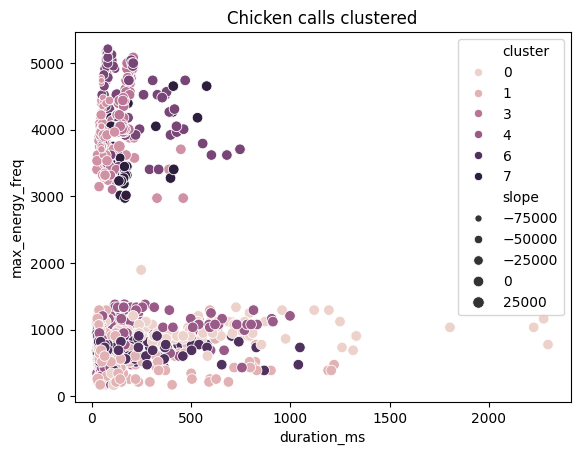

In [ ]:
# Scatterplot using hue to highlight cluster with duration on the x-axis and max_energy_freq on the y-axis 
sns.scatterplot(
    data=df,
    x='duration_ms',
    y='max_energy_freq',
    hue='cluster',
    size='slope',
    # palette='tab10',
    # sizes=(20, 200),       # adjust dot size range
    # alpha=0.8
)

plt.title("Chicken calls clustered")
plt.show()

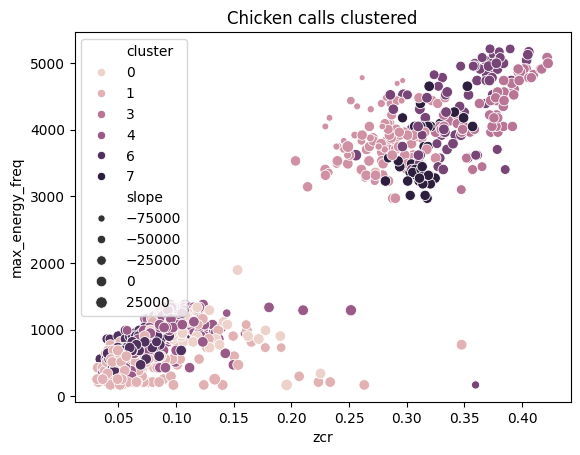

In [53]:
# Scatterplot using hue to highlight cluster with zero-crossing rate on the x-axis and max_energy_freq on the y-axis 
sns.scatterplot(
    data=df,
    x='zcr',
    y='max_energy_freq',
    hue='cluster',
    size='slope',
    # palette='tab10',
    # sizes=(20, 200),       # adjust dot size range
    # alpha=0.8
)

plt.title("Chicken calls clustered")
plt.show()

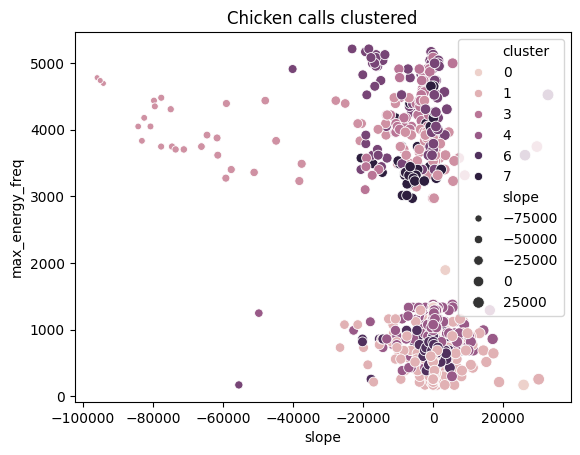

In [55]:
# Scatterplot using hue to highlight cluster with slope estimate on the x-axis and max_energy_freq on the y-axis 
sns.scatterplot(
    data=df,
    x='slope',
    y='max_energy_freq',
    hue='cluster',
    size='slope',
    # palette='tab10',
    # sizes=(20, 200),       # adjust dot size range
    # alpha=0.8
)

plt.title("Chicken calls clustered")
plt.show()

In [64]:
# add a column specifying if adults or chicks using filename
def assign_age(filename):
  if "chicks" in filename:
    return "chick"
  else:
    return "adult"
df['age'] = df["filename"].apply(assign_age)
df.tail(200)

,filename,call_num,start,end,duration_ms,time_to_next_call_ms,min_freq,max_freq,max_energy_freq,seg1_max_energy_freq,...,mfcc9_std,mfcc9_min,mfcc9_max,spectral_centroid,spectral_bandwidth,sample_rate,frame_length,vad_energy_threshold_used,cluster,age
895,chicks_20250404_3_descending_peep.wav,8,2.392,2.470,78,334.0,3100.781250,4048.242188,3488.378906,4005.175781,...,24.802566,-34.180813,43.506725,3735.044855,1270.200059,22050,512,0.010,5,chick
896,chicks_20250404_3_descending_peep.wav,9,2.804,2.878,74,82.0,3488.378906,4995.703125,4048.242188,4823.437500,...,16.570634,-31.449537,19.809023,4097.723161,1620.376477,22050,512,0.010,5,chick
897,chicks_20250404_3_descending_peep.wav,10,2.960,3.046,86,358.0,3057.714844,5167.968750,3574.511719,5167.968750,...,34.055255,-48.399144,47.686135,4113.089481,1399.467491,22050,512,0.010,3,chick
898,chicks_20250404_3_descending_peep.wav,11,3.404,3.500,96,104.0,3143.847656,4134.375000,3617.578125,5124.902344,...,30.838396,-40.532687,55.162905,4004.953208,1533.527800,22050,512,0.010,5,chick
899,chicks_20250404_3_descending_peep.wav,12,3.604,3.696,92,334.0,2971.582031,5254.101563,3445.312500,5211.035156,...,31.290366,-32.312383,54.775083,4209.387857,1399.429643,22050,512,0.010,3,chick
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1090,chickens_20201025_murmurs.wav,2,1.078,1.200,122,122.0,172.265625,1076.660156,215.332031,215.332031,...,6.042165,-22.127784,4.626768,1653.708501,2150.898274,22050,512,0.005,1,adult
1091,chickens_20201025_murmurs.wav,3,1.322,1.658,336,90.0,129.199219,1076.660156,387.597656,344.531250,...,7.992846,-40.085477,3.197494,1728.824871,2263.841987,22050,512,0.005,1,adult
1092,chickens_20241006_0600_coop_low_growl.wav,1,1.582,1.724,142,38.0,129.199219,818.261719,258.398438,215.332031,...,6.702341,-15.636600,11.868881,1970.696584,2664.557015,22050,512,0.005,1,adult
1093,chickens_20241006_0600_coop_low_growl.wav,2,1.762,2.266,504,26.0,172.265625,645.996094,258.398438,258.398438,...,8.506499,-35.763092,5.924839,1864.329548,2631.823427,22050,512,0.005,1,adult


In [ ]:
# See which clusters are mainly chicks vs. adults
pd.crosstab(df["cluster"], df["age"])

age,adult,chick
cluster,,
0,82,2
1,268,4
2,1,94
3,0,58
4,270,0
5,0,77
6,198,0
7,0,41


Per this, clusters 2, 3, 5, and 7 are primarily chicks
while clusters 0, 1, 3, and 6 are primarily adults
Chick and adult calls were rarely put in the same cluster

In [68]:
# mean and standard deviation for some time-domain measures
summary = (
    df.groupby("cluster")
      .agg({
          "duration_ms": ["mean", "std"],
          "time_to_next_call_ms": ["mean", "std"],
          "zcr": ["mean", "std"],
      })
)

print(summary)

        duration_ms             time_to_next_call_ms                    zcr  \
               mean         std                 mean          std      mean   
cluster                                                                       
0        586.119048  476.839126          1094.593370  1585.498140  0.104783   
1        158.235294  219.403291           161.680718   275.007099  0.074470   
2         80.273684   78.628461           163.980659   180.425774  0.278443   
3        158.862069   29.660327           230.276940    64.679006  0.373457   
4        168.311111  201.606391           202.071128   229.617476  0.094455   
5        185.896104  161.337468           186.485619   244.699554  0.348100   
6        171.363636  192.175203           211.725335   302.688372  0.063003   
7        188.195122  122.459630           271.867432   221.713553  0.313701   

                   
              std  
cluster            
0        0.029126  
1        0.038515  
2        0.026297  
3        0

In [ ]:
# According to these stats, cluster 0 has the longest calls with quite a big of variability
# while cluster 2 has the shortest calls

# Cluster 0's calls are also followed by longer periods of silence afterwards

# ZCR was highest in clusters 3, 5, 7, and low in clusters 6, 1, and 4

In [70]:
# mean and standard deviation for a bunch of measures
summary = (
    df.groupby("cluster")
      .agg({
          "max_energy_freq": ["mean", "std"],
          "spectral_bandwidth": ["mean", "std"],
          "freq_change": ["mean", "std"],
          "slope": ["mean", "std"],
      })
)

print(summary)

        max_energy_freq             spectral_bandwidth              \
                   mean         std               mean         std   
cluster                                                              
0            976.684570  204.545435        1605.879585  293.794167   
1            629.687859  316.190861        1985.474533  412.594203   
2           3828.376850  383.270614        1669.658777  308.945340   
3           4310.353246  456.434368        1320.848182  170.554877   
4            995.791016  223.285578        1749.777606  273.673579   
5           4361.452415  748.826278        1723.240125  239.650410   
6            722.776101  164.312072        1500.289582  313.688116   
7           3620.729326  450.182009        1342.060758  180.803969   

         freq_change                      slope                
                mean          std          mean           std  
cluster                                                        
0         310.693359   537.361881    

In [ ]:
# Per these stats, higher pitched calls were found in clusters that were mostly chick calls (5, 3, 2, 7)
# with freq of most energy above 3,600 Hz, while the adult clusters 0, 1, 3, 6 all had peak energy lower than 1000 Hz

# The slopes have very large standard deviations, so not sure they indicate a lot about the clusters

In [59]:
# Export results to csv
df.to_csv(f"../../data/output/chickens/{date.today()}_cluster_analysis_output.csv", header=True, index=False)